In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def sample_function(x, y):
    return y**2+1

In [55]:
def euler(num_steps, h, x0, y0, f_xy):
    x = np.array([x0])
    y = np.array([y0])
    for i in range(num_steps):
        x = np.append(x, x[-1] + h)
        y = np.append(y, y[-1]+h*f_xy(x[-1],y[-1]))

    return x, y


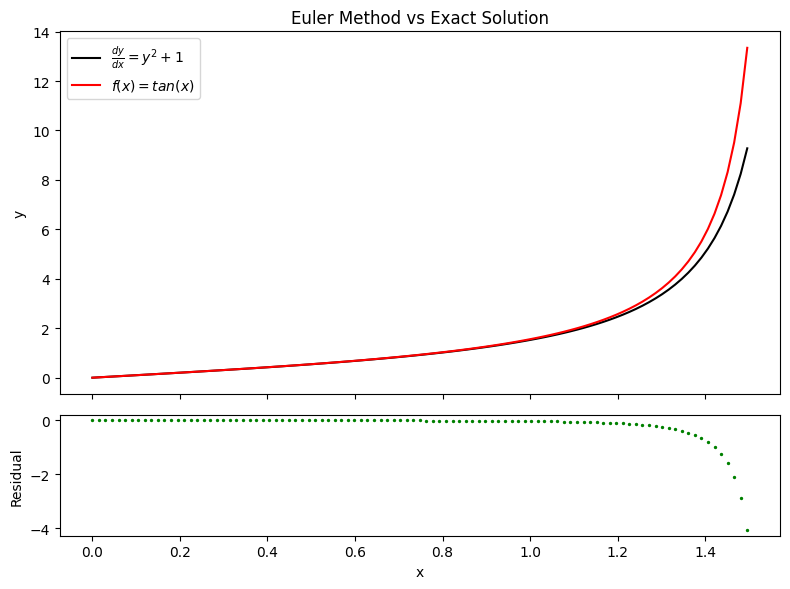

In [76]:
x_eu, y_eu = euler(100,(np.pi/2.1)/100,0,0,sample_function)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(x_eu,y_eu, color='black', label=r'$\frac{dy}{dx}=y^2+1$')
ax1.plot(x_eu,np.tan(x_eu), color='red', label=r'$f(x)=tan(x)$')
ax1.set_ylabel('y')
ax1.legend()
ax1.set_title("Euler Method vs Exact Solution")

ax2.scatter(x_eu, y_eu-np.tan(x_eu), color='green', s=2)
ax2.set_xlabel('x')
ax2.set_ylabel('Residual')

plt.tight_layout()

plt.savefig('Euler')

In [58]:
def runge_kutta(num_steps, h, x0, y0, f_xy):
    x = np.array([x0])
    y = np.array([y0])

    k1 = np.array([f_xy(x0,y0)])
    k2 = np.array([f_xy(x0+h/2, y0 + k1[0] * h/2)])
    k3 = np.array([f_xy(x0+h/2, y0 + k2[0] * h/2)])
    k4 = np.array([f_xy(x0+h, y0 + k3[0] * h)])
    
    for i in range(num_steps):
        x = np.append(x, x[-1]+h)
        y = np.append(y, y[-1] + h/6 * (k1[-1] + 2*k2[-1] + 2*k3[-1] + k4[-1]))

        k1 = np.append(k1, f_xy(x[-1],y[-1]))
        k2 = np.append(k2, f_xy(x[-1]+h/2, y[-1] + k1[-1] * h/2))
        k3 = np.append(k3, f_xy(x[-1]+h/2, y[-1] + k2[-1] * h/2))
        k4 = np.append(k4, f_xy(x[-1]+h, y[-1] + k3[-1] * h))

    return x, y, k1, k2, k3, k4


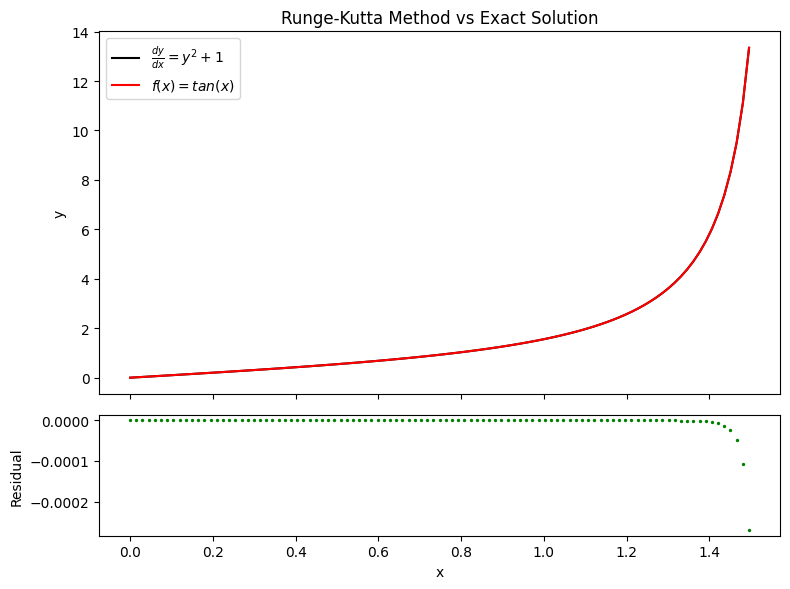

In [105]:
x_rk, y_rk, _,_,_,_ = runge_kutta(100,(np.pi/2.1)/100,0,0,sample_function)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(x_rk,y_rk, color='black', label=r'$\frac{dy}{dx}=y^2+1$')
ax1.plot(x_rk,np.tan(x_rk), color='red', label=r'$f(x)=tan(x)$')
ax1.set_ylabel('y')
ax1.legend()
ax1.set_title("Runge-Kutta Method vs Exact Solution")

ax2.scatter(x_rk, y_rk-np.tan(x_rk), color='green', s=2)
ax2.set_xlabel('x')
ax2.set_ylabel('Residual')

plt.tight_layout()

plt.savefig('Runge-Kutta')

In [119]:
num_steps = np.linspace(5,500,100).astype(int)
rk_stdev = np.array([])
rk_diff = np.array([])

_, y_rk_r, _,_,_,_ = runge_kutta(1000,(np.pi/2.1)/1000,0,0,sample_function)

for n in num_steps:
    x_rk, y_rk,_,_,_,_ = runge_kutta(n,(np.pi/2.1)/n,0,0,sample_function)

    rk_stdev = np.append(rk_stdev, np.std(y_rk-np.tan(x_rk)))
    rk_diff = np.append(rk_diff, 1-y_rk[-1]/y_rk_r[-1])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(x_rk,y_rk, color='black', label=r'$\frac{dy}{dx}=y^2+1$')
    ax1.plot(x_rk,np.tan(x_rk), color='red', label=r'$f(x)=tan(x)$')
    ax1.set_ylabel('y')
    ax1.legend()
    ax1.set_title(f"Runge-Kutta Method, {n} steps ")

    ax2.scatter(x_rk, y_rk-np.tan(x_rk), color='green', s=2)
    ax2.set_xlabel('x')
    ax2.set_ylabel('Residual')

    plt.tight_layout()
    plt.close()
    #plt.show()


In [120]:
eu_stdev = np.array([])
eu_diff = np.array([])

_, y_eu_r= euler(1000,(np.pi/2.1)/1000,0,0,sample_function)

for n in num_steps:
    x_eu, y_eu = euler(n,(np.pi/2.1)/n,0,0,sample_function)

    eu_stdev = np.append(eu_stdev, np.std(y_eu-np.tan(x_eu)))
    eu_diff = np.append(eu_diff, 1-y_eu[-1]/y_eu_r[-1])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(x_eu,y_eu, color='black', label=r'$\frac{dy}{dx}=y^2+1$')
    ax1.plot(x_eu,np.tan(x_eu), color='red', label=r'$f(x)=tan(x)$')
    ax1.set_ylabel('y')
    ax1.legend()
    ax1.set_title(f"Euler Method, {n} steps ")

    ax2.scatter(x_eu, y_eu-np.tan(x_eu), color='green', s=2)
    ax2.set_xlabel('x')
    ax2.set_ylabel('Residual')

    plt.tight_layout()
    plt.close()
    #plt.show()


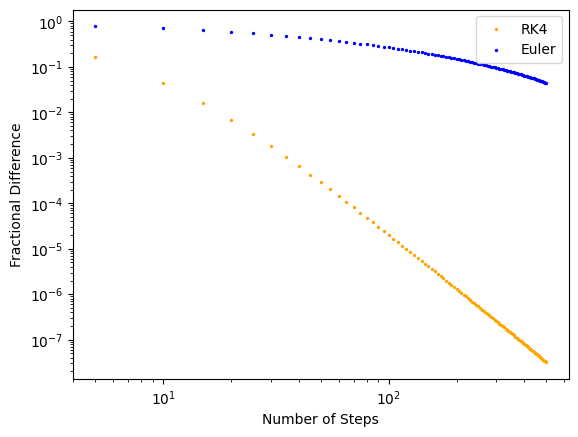

In [127]:
plt.scatter(num_steps, rk_diff, color='orange', label='RK4', s=2)
plt.scatter(num_steps, eu_diff, color='blue', label='Euler', s=2)

plt.xlabel('Number of Steps')
plt.ylabel('Fractional Difference')

plt.xscale('log')
plt.yscale('log')

plt.legend()
plt.savefig('frac_diff')